# 01 - Data Understanding
**Goal:** understand what each Olist table contains, how the tables connect, and what period the data covers *before* any cleaning.

Raw files are only read here, never modified.

In [1]:
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid", context="notebook"); pd.set_option("display.width", 160); pd.set_option("display.max_colwidth", 90)
ROOT = Path("..").resolve(); RAW = ROOT / "data" / "raw"; PROC = ROOT / "data" / "processed"

files = {"orders":"olist_orders_dataset.csv","customers":"olist_customers_dataset.csv","items":"olist_order_items_dataset.csv",
         "payments":"olist_order_payments_dataset.csv","reviews":"olist_order_reviews_dataset.csv","products":"olist_products_dataset.csv",
         "sellers":"olist_sellers_dataset.csv","geo":"olist_geolocation_dataset.csv","trans":"product_category_name_translation.csv"}
raw = {k: pd.read_csv(RAW / v) for k, v in files.items()}
pd.DataFrame({k: {"rows": len(v), "columns": v.shape[1], "missing_cells": int(v.isna().sum().sum()), "duplicate_rows": int(v.duplicated().sum())} for k, v in raw.items()}).T

,rows,columns,missing_cells,duplicate_rows
orders,99441,8,4908,0
customers,99441,5,0,0
items,112650,7,0,0
payments,103886,5,0,0
reviews,99224,7,145903,0
products,32951,9,2448,0
sellers,3095,4,0,0
geo,1000163,5,0,261831
trans,71,2,0,0


## Q1. What are the primary keys, and do the keys behave as expected?
*Why it matters:* wrong key assumptions cause double-counted revenue after joins.

In [2]:
o, c, i, p, r = raw["orders"], raw["customers"], raw["items"], raw["payments"], raw["reviews"]
keys = pd.DataFrame([
 ("orders.order_id", o.order_id.is_unique, o.order_id.nunique()),
 ("customers.customer_id", c.customer_id.is_unique, c.customer_id.nunique()),
 ("customers.customer_unique_id", c.customer_unique_id.is_unique, c.customer_unique_id.nunique()),
 ("order_items (order_id, order_item_id)", not i.duplicated(["order_id","order_item_id"]).any(), len(i)),
 ("payments (order_id, payment_sequential)", not p.duplicated(["order_id","payment_sequential"]).any(), len(p)),
 ("reviews.review_id", r.review_id.is_unique, r.review_id.nunique()),
 ("reviews.order_id", r.order_id.is_unique, r.order_id.nunique()),
 ("products.product_id", raw["products"].product_id.is_unique, len(raw["products"])),
 ("sellers.seller_id", raw["sellers"].seller_id.is_unique, len(raw["sellers"]))], columns=["key","is_unique","distinct_values"])
keys

,key,is_unique,distinct_values
0,orders.order_id,True,99441
1,customers.customer_id,True,99441
2,customers.customer_unique_id,False,96096
3,"order_items (order_id, order_item_id)",True,112650
4,"payments (order_id, payment_sequential)",True,103886
5,reviews.review_id,False,98410
6,reviews.order_id,False,98673
7,products.product_id,True,32951
8,sellers.seller_id,True,3095


**Finding:** `customer_id` is unique per *order*, so it cannot be used to find repeat buyers - `customer_unique_id` must be used (96,096 real customers behind 99,441 ids). `review_id` and `order_id` in the reviews table are **not** unique, so reviews need de-duplication before joining to orders (handled in notebook 02).

## Q2. What time period does the data cover, and is every month complete?

First order: 2016-09-04 21:15:19 | Last order: 2018-10-17 17:30:18


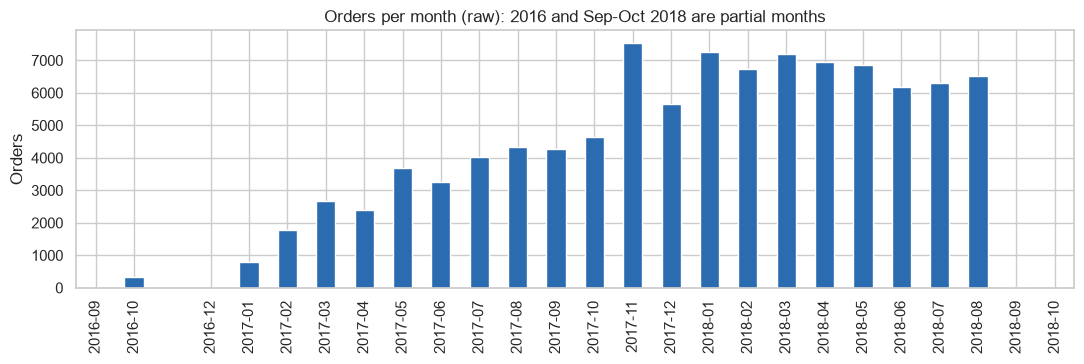

In [3]:
ts = pd.to_datetime(o.order_purchase_timestamp)
print("First order:", ts.min(), "| Last order:", ts.max())
m = ts.dt.to_period("M").value_counts().sort_index()
fig, ax = plt.subplots(figsize=(11, 3.8)); m.plot(kind="bar", ax=ax, color="#2b6cb0")
ax.set_title("Orders per month (raw): 2016 and Sep-Oct 2018 are partial months"); ax.set_xlabel(""); ax.set_ylabel("Orders"); plt.tight_layout(); plt.show()

**Finding:** only 4 orders in Sep 2016, one in Dec 2016, and 20 orders in Sep-Oct 2018. Trend and growth analysis in later notebooks therefore uses the **full-month window Jan 2017 - Aug 2018**.
**Implication:** including partial months would create fake growth/decline spikes.

## Q3. What order statuses exist?

In [4]:
s = o.order_status.value_counts().to_frame("orders"); s["share_%"] = (s.orders / s.orders.sum() * 100).round(2); s

,orders,share_%
order_status,,
delivered,96478,97.02
shipped,1107,1.11
canceled,625,0.63
unavailable,609,0.61
invoiced,314,0.32
processing,301,0.30
created,5,0.01
approved,2,0.00


**Finding:** ~97% of orders are `delivered`. `canceled` and `unavailable` orders are not real sales and will be flagged so revenue is not overstated.

## Q4. Are the tables linked correctly (referential integrity)?

In [5]:
pr, s_ = raw["products"], raw["sellers"]
checks = {"orders -> customers (missing)": (~o.customer_id.isin(c.customer_id)).sum(),
 "items -> orders (missing)": (~i.order_id.isin(o.order_id)).sum(), "items -> products (missing)": (~i.product_id.isin(pr.product_id)).sum(),
 "items -> sellers (missing)": (~i.seller_id.isin(s_.seller_id)).sum(), "payments -> orders (missing)": (~p.order_id.isin(o.order_id)).sum(),
 "reviews -> orders (missing)": (~r.order_id.isin(o.order_id)).sum(), "orders with no items": (~o.order_id.isin(i.order_id)).sum(),
 "product categories without translation": pr.product_category_name.dropna()[~pr.product_category_name.dropna().isin(raw["trans"].product_category_name)].nunique()}
pd.Series(checks, name="count").to_frame()

,count
orders -> customers (missing),0
items -> orders (missing),0
items -> products (missing),0
items -> sellers (missing),0
payments -> orders (missing),0
reviews -> orders (missing),0
orders with no items,775
product categories without translation,2


**Finding:** no orphan foreign keys. 775 orders have no items (mostly `unavailable`/`canceled`), and 2 product categories are missing from the translation file.

**Money fields available:** `price` (product value), `freight_value` (shipping), `payment_value` (cash paid). **No cost or profit field exists**, so profit cannot be calculated; only revenue and clearly labelled estimated proxies are possible.